<a href="https://colab.research.google.com/github/ambika-1513/Computer-vision-learning/blob/main/LiDaR_sensorFusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open3d -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import open3d as o3d


In [ ]:
num_points = 1000
points = np.random.rand(num_points ,3)


In [ ]:
points.shape

(1000, 3)

In [ ]:
points[:5]

array([[0.57308007, 0.13759148, 0.23124871],
       [0.11226054, 0.99020447, 0.77429113],
       [0.82329437, 0.43937172, 0.92813174],
       [0.34825943, 0.18392888, 0.62292997],
       [0.45248773, 0.96849633, 0.78425822]])

In [ ]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
print(pcd)
print(pcd.points)

PointCloud with 1000 points.
std::vector<Eigen::Vector3d> with 1000 elements.
Use numpy.asarray() to access data.


In [ ]:
o3d.visualization.draw_geometries([pcd])

[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


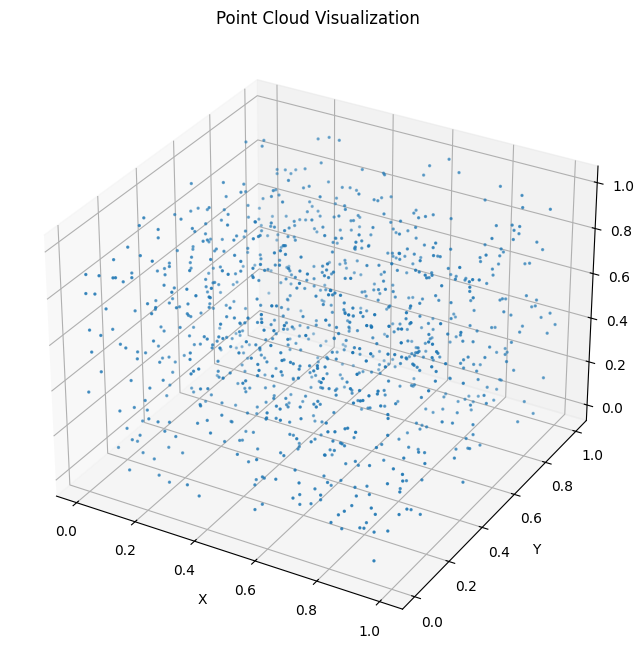

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get our points back as a numpy array
points_np = np.asarray(pcd.points)

# Create a 3D plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points_np[:,0], points_np[:,1], points_np[:,2], s=2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Point Cloud Visualization')

plt.show()

In [ ]:
# Simulate a ground plane (flat surface)
x_ground = np.random.uniform(-10, 10, 2000)
y_ground = np.random.uniform(-10, 10, 2000)
z_ground = np.zeros(2000)  # flat, all at height 0

ground_points = np.column_stack((x_ground, y_ground, z_ground))

# Simulate a "car" — a cluster of points forming a box shape
x_car = np.random.uniform(2, 4, 300)   # car located 2-4m ahead
y_car = np.random.uniform(-1, 1, 300)  # 1m wide
z_car = np.random.uniform(0, 1.5, 300) # 1.5m tall

car_points = np.column_stack((x_car, y_car, z_car))

# Combine both into one point cloud
all_points = np.vstack((ground_points, car_points))

print("Ground points shape:", ground_points.shape)
print("Car points shape:", car_points.shape)
print("Combined shape:", all_points.shape)

Ground points shape: (2000, 3)
Car points shape: (300, 3)
Combined shape: (2300, 3)


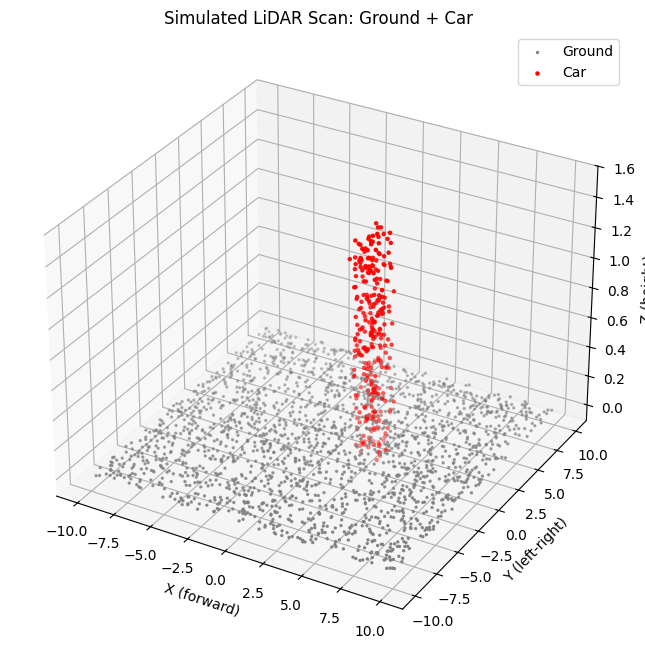

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot ground points in gray
ax.scatter(ground_points[:,0], ground_points[:,1], ground_points[:,2],
           s=2, c='gray', label='Ground')

# Plot car points in red
ax.scatter(car_points[:,0], car_points[:,1], car_points[:,2],
           s=5, c='red', label='Car')

ax.set_xlabel('X (forward)')
ax.set_ylabel('Y (left-right)')
ax.set_zlabel('Z (height)')
ax.set_title('Simulated LiDAR Scan: Ground + Car')
ax.legend()

plt.show()

In [ ]:
pcd_combined = o3d.geometry.PointCloud()
pcd_combined.points = o3d.utility.Vector3dVector(all_points)

plane_model , inliers = pcd_combined.segment_plane(
                            distance_threshold=0.1,
                            ransac_n=3,
                            num_iterations=1000
                        )
print("Plane_equation", plane_model)
print("Number_of_ground_points_found" , len(inliers))
print("Total points" , len(all_points))

Plane_equation [-3.82720907e-05  6.03521848e-07  9.99999999e-01 -4.41180892e-04]
Number_of_ground_points_found 2017
Total points 2300


In [ ]:
# inliers = indices of points RANSAC identified as ground
# We need to find which points are NOT in inliers (the "outliers" - non-ground)

all_indices = np.arange(len(all_points))
outlier_indices = np.setdiff1d(all_indices, inliers)

ground_detected = all_points[inliers]
non_ground_detected = all_points[outlier_indices]

print("Ground detected shape:", ground_detected.shape)
print("Non-ground detected shape:", non_ground_detected.shape)

Ground detected shape: (2017, 3)
Non-ground detected shape: (283, 3)


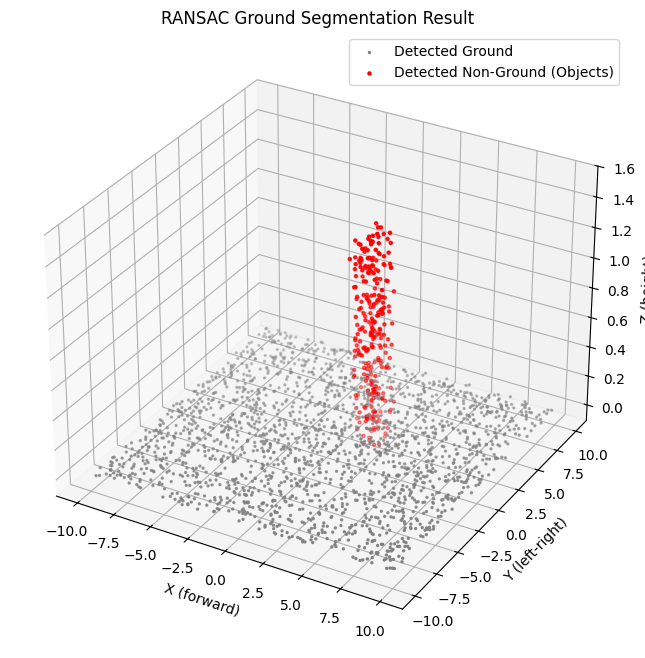

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot what RANSAC found as ground (should mostly match our real ground)
ax.scatter(ground_detected[:,0], ground_detected[:,1], ground_detected[:,2],
           s=2, c='gray', label='Detected Ground')

# Plot what RANSAC found as NOT ground (should mostly match our real car)
ax.scatter(non_ground_detected[:,0], non_ground_detected[:,1], non_ground_detected[:,2],
           s=5, c='red', label='Detected Non-Ground (Objects)')

ax.set_xlabel('X (forward)')
ax.set_ylabel('Y (left-right)')
ax.set_zlabel('Z (height)')
ax.set_title('RANSAC Ground Segmentation Result')
ax.legend()

plt.show()

In [ ]:
import numpy as np
scan = np.fromfile("/content/000000.bin",dtype=np.float32)       #fromfile() reads raw binary data directly from a file and converts it into a NumPy array
print("Total_raw_values:" , scan.shape)
print("First 12 values (3 points worth):", scan[:12])

Total_raw_values: (461536,)
First 12 values (3 points worth): [1.8324e+01 4.9000e-02 8.2900e-01 0.0000e+00 1.8344e+01 1.0600e-01
 8.2900e-01 0.0000e+00 5.1299e+01 5.0500e-01 1.9440e+00 0.0000e+00]


In [ ]:
points = scan.reshape(-1,4)

In [ ]:
points.shape

(115384, 4)

In [ ]:
points[:3]

array([[1.8324e+01, 4.9000e-02, 8.2900e-01, 0.0000e+00],
       [1.8344e+01, 1.0600e-01, 8.2900e-01, 0.0000e+00],
       [5.1299e+01, 5.0500e-01, 1.9440e+00, 0.0000e+00]], dtype=float32)

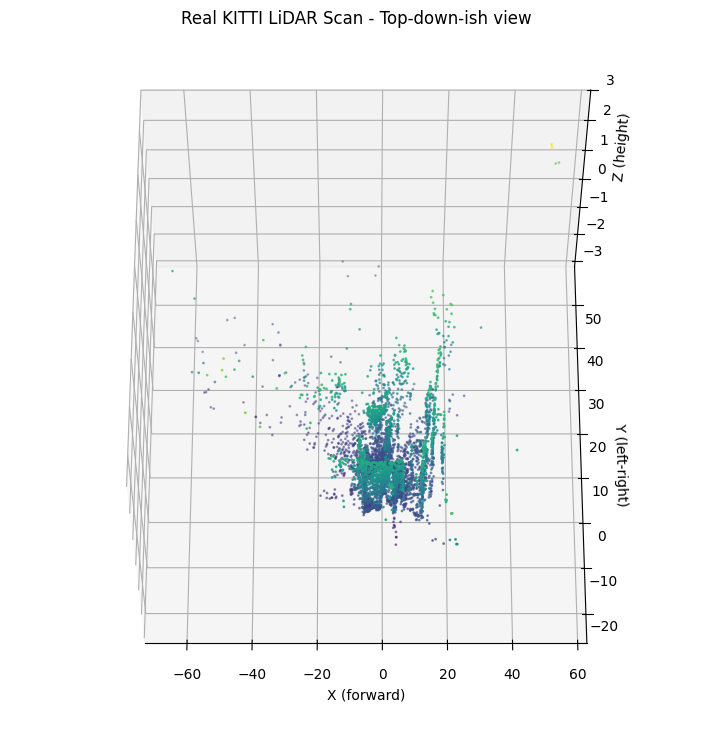

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

xyz = points[:, :3]
sample_size = 5000
indices = np.random.choice(len(xyz), sample_size, replace=False)
xyz_sample = xyz[indices]

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xyz_sample[:,0], xyz_sample[:,1], xyz_sample[:,2], s=1, c=xyz_sample[:,2], cmap='viridis')

ax.set_xlabel('X (forward)')
ax.set_ylabel('Y (left-right)')
ax.set_zlabel('Z (height)')
ax.set_title('Real KITTI LiDAR Scan - Top-down-ish view')

# Set a better viewing angle - looking down from above, slightly angled
ax.view_init(elev=60, azim=-90)

plt.show()

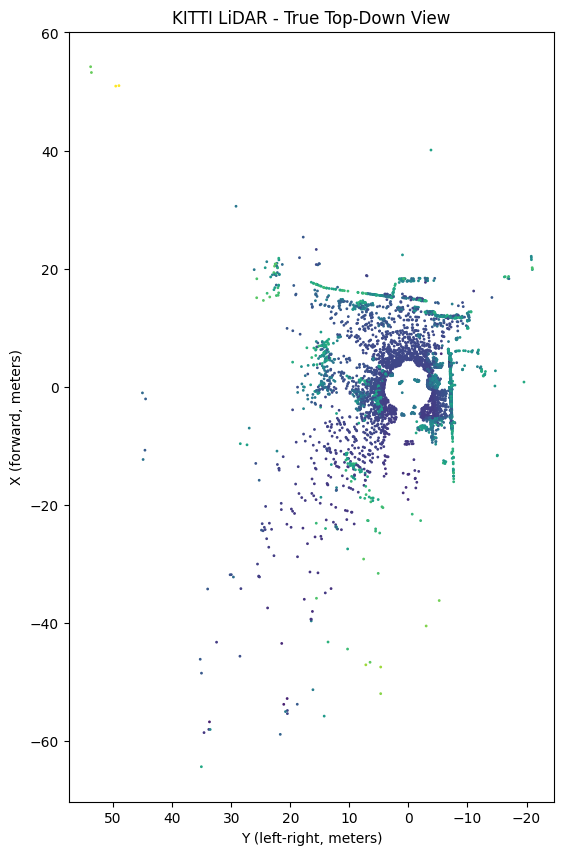

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

# Pure 2D top-down scatter plot - just X and Y, ignore height for now
ax.scatter(xyz_sample[:,1], xyz_sample[:,0], s=1, c=xyz_sample[:,2], cmap='viridis')

ax.set_xlabel('Y (left-right, meters)')
ax.set_ylabel('X (forward, meters)')
ax.set_title('KITTI LiDAR - True Top-Down View')
ax.set_aspect('equal')  # critical - keeps real-world proportions correct
ax.invert_xaxis()  # so "left" appears on the left, matching driver's perspective

plt.show()

In [ ]:
pcd_kitti = o3d.geometry.PointCloud()
pcd_kitti.points = o3d.utility.Vector3dVector(points[:,:3])

plane_model, inliers = pcd_kitti.segment_plane(distance_threshold =0.2, ransac_n = 3, num_iterations = 1000)


In [ ]:
print("Plane_equation:", plane_model)
print("Ground points", len(inliers))
print("Total points", len(points[:,:3]))
print("Groun points vs total points" , len(inliers)/len(xyz)*100, "%")

Plane_equation: [-0.01498909 -0.01086181  0.99982866  1.72111907]
Ground points 48662
Total points 115384
Groun points vs total points 42.17395826111073 %


Ground points: (48662, 3)
Object points: (66722, 3)


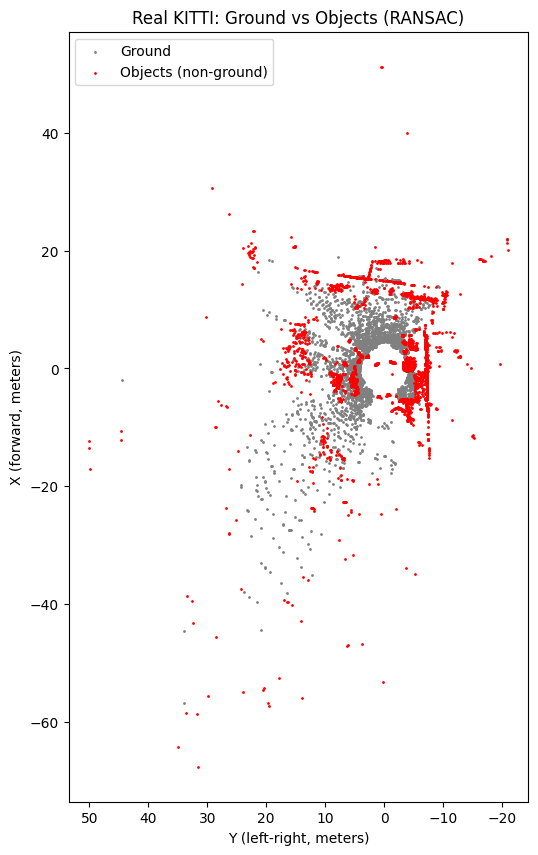

In [ ]:
all_indices = np.arange(len(xyz))
outlier_indices = np.setdiff1d(all_indices, inliers)

ground_kitti = xyz[inliers]
objects_kitti = xyz[outlier_indices]

print("Ground points:", ground_kitti.shape)
print("Object points:", objects_kitti.shape)

# Sample both for faster plotting
sample_n = 3000
ground_sample = ground_kitti[np.random.choice(len(ground_kitti), min(sample_n, len(ground_kitti)), replace=False)]
object_sample = objects_kitti[np.random.choice(len(objects_kitti), min(sample_n, len(objects_kitti)), replace=False)]

fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(ground_sample[:,1], ground_sample[:,0], s=1, c='gray', label='Ground')
ax.scatter(object_sample[:,1], object_sample[:,0], s=1, c='red', label='Objects (non-ground)')

ax.set_xlabel('Y (left-right, meters)')
ax.set_ylabel('X (forward, meters)')
ax.set_title('Real KITTI: Ground vs Objects (RANSAC)')
ax.set_aspect('equal')
ax.invert_xaxis()
ax.legend()

plt.show()

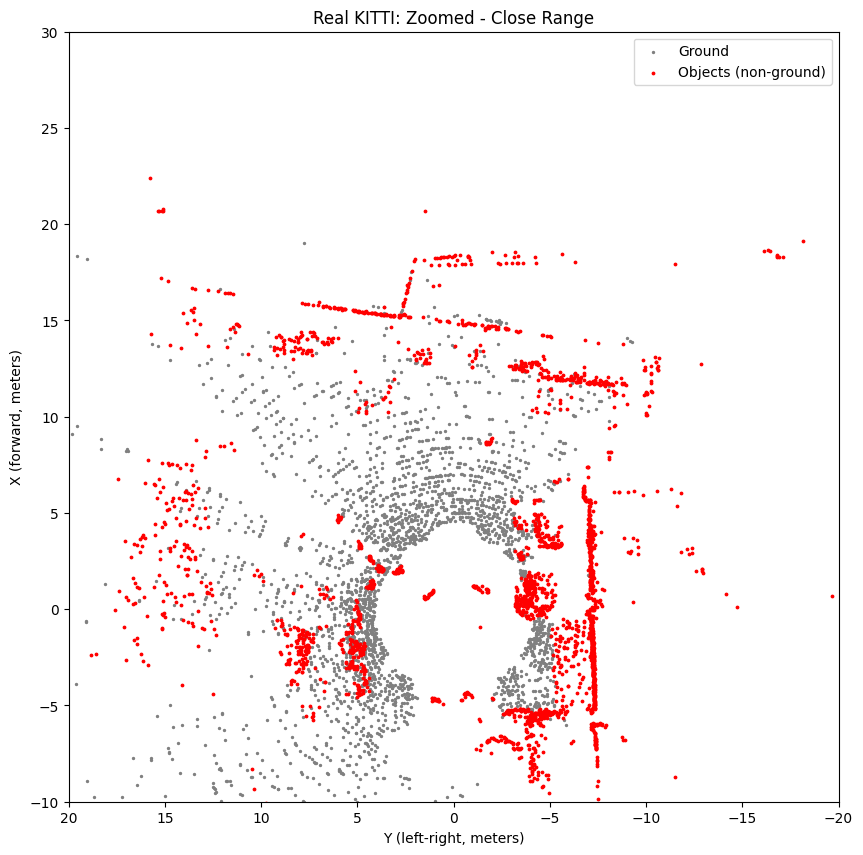

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(ground_sample[:,1], ground_sample[:,0], s=2, c='gray', label='Ground')
ax.scatter(object_sample[:,1], object_sample[:,0], s=3, c='red', label='Objects (non-ground)')

ax.set_xlabel('Y (left-right, meters)')
ax.set_ylabel('X (forward, meters)')
ax.set_title('Real KITTI: Zoomed - Close Range')
ax.set_aspect('equal')
ax.invert_xaxis()
ax.set_xlim(20, -20)   # zoom into +/- 20m left-right
ax.set_ylim(-10, 30)   # zoom into the near-range forward area
ax.legend()

plt.show()

In [ ]:
with open("/content/000000.txt" , "r") as f:
  calib_content = f.read()
print(calib_content)

P0: 7.070493000000e+02 0.000000000000e+00 6.040814000000e+02 0.000000000000e+00 0.000000000000e+00 7.070493000000e+02 1.805066000000e+02 0.000000000000e+00 0.000000000000e+00 0.000000000000e+00 1.000000000000e+00 0.000000000000e+00
P1: 7.070493000000e+02 0.000000000000e+00 6.040814000000e+02 -3.797842000000e+02 0.000000000000e+00 7.070493000000e+02 1.805066000000e+02 0.000000000000e+00 0.000000000000e+00 0.000000000000e+00 1.000000000000e+00 0.000000000000e+00
P2: 7.070493000000e+02 0.000000000000e+00 6.040814000000e+02 4.575831000000e+01 0.000000000000e+00 7.070493000000e+02 1.805066000000e+02 -3.454157000000e-01 0.000000000000e+00 0.000000000000e+00 1.000000000000e+00 4.981016000000e-03
P3: 7.070493000000e+02 0.000000000000e+00 6.040814000000e+02 -3.341081000000e+02 0.000000000000e+00 7.070493000000e+02 1.805066000000e+02 2.330660000000e+00 0.000000000000e+00 0.000000000000e+00 1.000000000000e+00 3.201153000000e-03
R0_rect: 9.999128000000e-01 1.009263000000e-02 -8.511932000000e-03 -1

In [ ]:
import numpy as np

def parse_calib_line(line):
    # Each line looks like "P2: 7.07e+02 0.0 ... "
    # We split off the label, then convert remaining numbers to floats
    values = line.split()[1:]  # skip the first item (the label like "P2:")
    return np.array([float(v) for v in values])

# Paste your calibration content into this dictionary manually for now
calib_lines = {
    "P2": "7.070493000000e+02 0.000000000000e+00 6.040814000000e+02 4.575831000000e+01 0.000000000000e+00 7.070493000000e+02 1.805066000000e+02 -3.454157000000e-01 0.000000000000e+00 0.000000000000e+00 1.000000000000e+00 4.981016000000e-03",
    "R0_rect": "9.999128000000e-01 1.009263000000e-02 -8.511932000000e-03 -1.012729000000e-02 9.999406000000e-01 -4.037671000000e-03 8.470675000000e-03 4.123522000000e-03 9.999556000000e-01",
    "Tr_velo_to_cam": "6.927964000000e-03 -9.999722000000e-01 -2.757829000000e-03 -2.457729000000e-02 -1.162982000000e-03 2.749836000000e-03 -9.999955000000e-01 -6.127237000000e-02 9.999753000000e-01 6.931141000000e-03 -1.143899000000e-03 -3.321029000000e-01"
}

P2 = np.array([float(v) for v in calib_lines["P2"].split()]).reshape(3, 4)
R0_rect = np.array([float(v) for v in calib_lines["R0_rect"].split()]).reshape(3, 3)
Tr_velo_to_cam = np.array([float(v) for v in calib_lines["Tr_velo_to_cam"].split()]).reshape(3, 4)

print("P2 shape:", P2.shape)
print(P2)
print("\nR0_rect shape:", R0_rect.shape)
print(R0_rect)
print("\nTr_velo_to_cam shape:", Tr_velo_to_cam.shape)
print(Tr_velo_to_cam)

P2 shape: (3, 4)
[[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]

R0_rect shape: (3, 3)
[[ 0.9999128   0.01009263 -0.00851193]
 [-0.01012729  0.9999406  -0.00403767]
 [ 0.00847068  0.00412352  0.9999556 ]]

Tr_velo_to_cam shape: (3, 4)
[[ 0.00692796 -0.9999722  -0.00275783 -0.02457729]
 [-0.00116298  0.00274984 -0.9999955  -0.06127237]
 [ 0.9999753   0.00693114 -0.0011439  -0.3321029 ]]


In [ ]:
def read_calib_file(filepath):
    calib = {}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            key, value = line.split(':', 1)
            calib[key] = np.array([float(x) for x in value.split()])
    return calib

calib = read_calib_file("000000.txt")

# Now extract just the 3 matrices we need, reshaping them properly
P2 = calib["P2"].reshape(3, 4)
R0_rect = calib["R0_rect"].reshape(3, 3)
Tr_velo_to_cam = calib["Tr_velo_to_cam"].reshape(3, 4)

print("P2:\n", P2)
print("\nR0_rect:\n", R0_rect)
print("\nTr_velo_to_cam:\n", Tr_velo_to_cam)

P2:
 [[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]

R0_rect:
 [[ 0.9999128   0.01009263 -0.00851193]
 [-0.01012729  0.9999406  -0.00403767]
 [ 0.00847068  0.00412352  0.9999556 ]]

Tr_velo_to_cam:
 [[ 0.00692796 -0.9999722  -0.00275783 -0.02457729]
 [-0.00116298  0.00274984 -0.9999955  -0.06127237]
 [ 0.9999753   0.00693114 -0.0011439  -0.3321029 ]]


In [ ]:
# Let's grab just the FIRST 5 real LiDAR points from our KITTI scan
sample_points = xyz[:5]
print("Sample LiDAR points (x,y,z):")
print(sample_points)

Sample LiDAR points (x,y,z):
[[1.8324e+01 4.9000e-02 8.2900e-01]
 [1.8344e+01 1.0600e-01 8.2900e-01]
 [5.1299e+01 5.0500e-01 1.9440e+00]
 [1.8317e+01 2.2100e-01 8.2900e-01]
 [1.8352e+01 2.5100e-01 8.3000e-01]]


In [ ]:
# Add a column of 1s to make points "homogeneous" (turns [x,y,z] into [x,y,z,1])
ones = np.ones((sample_points.shape[0], 1))
points_homogeneous = np.hstack((sample_points, ones))

print("Homogeneous points shape:", points_homogeneous.shape)
print(points_homogeneous)

Homogeneous points shape: (5, 4)
[[1.83239994e+01 4.89999987e-02 8.28999996e-01 1.00000000e+00]
 [1.83439999e+01 1.05999999e-01 8.28999996e-01 1.00000000e+00]
 [5.12989998e+01 5.04999995e-01 1.94400001e+00 1.00000000e+00]
 [1.83169994e+01 2.21000001e-01 8.28999996e-01 1.00000000e+00]
 [1.83519993e+01 2.50999987e-01 8.29999983e-01 1.00000000e+00]]


In [ ]:
# Apply Tr_velo_to_cam: converts LiDAR coordinates -> camera coordinates
points_cam = Tr_velo_to_cam @ points_homogeneous.T

print("Points in camera coordinates, shape:", points_cam.shape)
print(points_cam.T)  # transpose back for easier reading

Points in camera coordinates, shape: (3, 5)
[[ 5.10858415e-02 -9.11444375e-01  1.79908352e+01]
 [-5.77401151e-03 -9.11310895e-01  1.80112303e+01]
 [-1.79526842e-01 -2.06353477e+00  5.09669063e+01]
 [-1.20957875e-01 -9.10963263e-01  1.79850276e+01]
 [-1.50717307e-01 -9.11921454e-01  1.80202334e+01]]


In [ ]:
# Apply R0_rect rectification
points_rect = R0_rect @ points_cam

print("Rectified points shape:", points_rect.shape)
print(points_rect.T)

Rectified points shape: (3, 5)
[[-0.11125425 -0.98454867 17.98671081]
 [-0.1682814  -0.98392171 18.00662386]
 [-0.63416452 -2.26738168 50.95461361]
 [-0.28322867 -0.9823018  17.97944809]
 [-0.31329485 -0.9831007  18.01439626]]


In [ ]:
# Apply R0_rect rectification
points_rect = R0_rect @ points_cam

print("Rectified points shape:", points_rect.shape)
print(points_rect.T)

Rectified points shape: (3, 5)
[[-0.11125425 -0.98454867 17.98671081]
 [-0.1682814  -0.98392171 18.00662386]
 [-0.63416452 -2.26738168 50.95461361]
 [-0.28322867 -0.9823018  17.97944809]
 [-0.31329485 -0.9831007  18.01439626]]


In [ ]:
# We need homogeneous coordinates again for this projection step
ones_row = np.ones((1, points_rect.shape[1]))
points_rect_homogeneous = np.vstack((points_rect, ones_row))

# Apply P2 (camera projection matrix)
points_2d_homogeneous = P2 @ points_rect_homogeneous

print("2D homogeneous points shape:", points_2d_homogeneous.shape)
print(points_2d_homogeneous.T)

2D homogeneous points shape: (3, 5)
[[1.08325335e+04 2.55025015e+03 1.79916918e+01]
 [1.08042416e+04 2.55428788e+03 1.80116049e+01]
 [3.03781071e+04 7.59414801e+03 5.09595946e+01]
 [1.07065518e+04 2.55052783e+03 1.79844291e+01]
 [1.07064051e+04 2.55627134e+03 1.80193773e+01]]


In [ ]:
# Divide first two values by the third (depth) to get actual pixel coordinates
u = points_2d_homogeneous[0, :] / points_2d_homogeneous[2, :]
v = points_2d_homogeneous[1, :] / points_2d_homogeneous[2, :]

print("Pixel U coordinates (horizontal):", u)
print("Pixel V coordinates (vertical):", v)

Pixel U coordinates (horizontal): [602.0853193  599.8489135  596.12144246 595.32342031 594.16066125]
Pixel V coordinates (vertical): [141.7459889  141.81345282 149.02292823 141.81867067 141.86235751]
